## 3CSD Group 8 - Evaluating Algorithmic Bias and Feature Thresholds in Predicting Geopolitical Attack Success 

Members:
1. Abelardo, Aasen Sofia P.
2. Aquino, Matthew Benedict U.
3. Balingit, Den Mar F.
4. Gumban, Joevanni Paulo T.




In [ ]:
# Imports
print("Running Cell 1: imports...", flush=True)

from pathlib import Path
import os, random, joblib, warnings, urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

print("Importing optional model libraries...", flush=True)
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded.", flush=True)
except Exception as e:
    XGBClassifier = None
    print(f"XGBoost not available: {e}", flush=True)

try:
    import torch
    from torch import nn
    print("PyTorch loaded.", flush=True)
except Exception as e:
    torch, nn = None, None
    print(f"PyTorch not available: {e}", flush=True)

print("Imports loaded.", flush=True)

Running Cell 1: imports...
Importing optional model libraries...
XGBoost loaded.
PyTorch loaded.
Imports loaded.


In [ ]:
# 2. Configs
print("Running Cell 2: configs...", flush=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

#  Main experiment switches for controlling the flow.
SPLIT_MODE = "random"             # "temporal" or "random"
TRAINING_PROFILE = "max"     # "submission" for faster reproducible run, "max" for heavier full-potential run
USE_SAMPLE = False                  # True for quick checking only
SAMPLE_NROWS = 5000
CACHE_DATA = True                   # Saves a cleaned .pkl copy so reruns avoid slow Excel loading
REBUILD_DATA_CACHE = False          # Set True only when raw files/features change
DOWNLOAD_DATA_IF_MISSING = False    # Set True to try downloading raw GTD files if data/raw is empty
GTD_MAIN_URL = os.getenv("GTD_MAIN_URL", "https://www.start.umd.edu/system/files/globalterrorismdb_0522dist.xlsx")  # Optional official/direct URL supplied by user
GTD_SUPP_URL = os.getenv("GTD_SUPP_URL", "https://www.start.umd.edu/system/files/globalterrorismdb_2021Jan-June_1222dist.xlsx")  # Optional official/direct URL supplied by user
USE_GPU = True
RUN_LEARNING_CURVES = True
RUN_FEATURE_IMPORTANCE = True

if TRAINING_PROFILE == "max":
    # Heavier settings that use more of the dataset and train models longer.
    # Use this for final result generation if runtime is acceptable.
    USE_SAMPLE = False
    MODEL_EPOCHS = 60
    CURVE_EPOCHS = 20
    XGB_N_ESTIMATORS = 800
    XGB_MAX_DEPTH = 5
    LEARNING_CURVE_FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
    LEARNING_CURVE_MAX_TRAIN_N = None       # None means no cap; uses all training rows for the 1.00 point
    PERMUTATION_SAMPLE_N = 10000
    N_PERM_REPEATS = 5
else:
    # Lighter settings for notebook submission and reruns.
    MODEL_EPOCHS = 25
    CURVE_EPOCHS = 10
    XGB_N_ESTIMATORS = 300
    XGB_MAX_DEPTH = 4
    LEARNING_CURVE_FRACTIONS = [0.25, 0.50, 1.00]
    LEARNING_CURVE_MAX_TRAIN_N = 60000
    PERMUTATION_SAMPLE_N = 3000
    N_PERM_REPEATS = 2

print("Cell 2 complete: configs set.", flush=True)
print("Split mode:", SPLIT_MODE)
print("Training profile:", TRAINING_PROFILE)
print("Download if missing:", DOWNLOAD_DATA_IF_MISSING)

Running Cell 2: configs...
Cell 2 complete: configs set.
Split mode: random
Training profile: max
Download if missing: False


In [ ]:
# 3. Remaining setup and helper functions
print("Running Cell 3: paths and helper functions...", flush=True)

# Paths for clearner location keepings
ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" # This path is for the raw dataset files and can be changable.
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "results" / "light_reproducible" / SPLIT_MODE 
FIG = OUT / "figures"; TAB = OUT / "tables"; MOD = ROOT / "models" / "light_reproducible" / SPLIT_MODE
for d in [FIG, TAB, MOD, PROCESSED]: d.mkdir(parents=True, exist_ok=True)

TARGET = "success"; ID = "eventid"
NUM = ["iyear","imonth","iday","extended","latitude","longitude","specificity","vicinity","doubtterr","multiple","suicide","guncertain1","individual","claimed","INT_LOG","INT_IDEO","INT_MISC","INT_ANY"]
CAT = ["region_txt","country_txt","attacktype1_txt","targtype1_txt","targsubtype1_txt","natlty1_txt","weaptype1_txt","weapsubtype1_txt"]
LEAKAGE_EXCLUDED = ["nkill","nwound","property","ransom","hostkidoutcome","nreleased"]

# This area is assisted by AI for cleaning the dataset and engineering features, but the modeling and analysis are entirely human-driven. 
# The code is designed to be clear and reproducible, with a focus on simplicity and interpretability rather than raw performance. 
# The dataset is loaded from the "raw" directory, processed, and the results are saved in the "results" directory, organized by split mode.
def resolve_file(stems):
    for stem in stems:
        for ext in [".xlsx", ".xls", ".csv", ".parquet"]:
            p = RAW / f"{stem}{ext}"
            if p.exists(): return p
    raise FileNotFoundError(f"Missing one of {stems} in {RAW}")

def raw_file_exists(stems):
    try:
        resolve_file(stems)
        return True
    except FileNotFoundError:
        return False

def download_file(url, destination):
    print(f"Downloading {destination.name} ...")
    urllib.request.urlretrieve(url, destination)
    print(f"Saved: {destination}")

def get_cache_path():
    cache_name = f"gtd_light_{'sample_' + str(SAMPLE_NROWS) if USE_SAMPLE else 'full'}.pkl"
    return PROCESSED / cache_name

def verify_raw_data_available():
    main_ok = raw_file_exists(["globalterrorismdb_0522dist", "globalterrorismdb", "gtd"])
    supp_ok = raw_file_exists(["globalterrorismdb_2021Jan-June_1222dist", "gtd_2021Jan-June", "gtd_2021"])
    missing = []
    if not main_ok:
        missing.append("main GTD file")
    if not supp_ok:
        missing.append("2021 supplement file")
    if missing:
        raise FileNotFoundError(
            f"Missing {', '.join(missing)} in {RAW}. Run the download cell with DOWNLOAD_DATA_IF_MISSING=True, "
            "or manually place the GTD Excel/CSV files in data/raw/."
        )
    print("Raw GTD files are available in:", RAW)

def download_raw_data():
    main_ok = raw_file_exists(["globalterrorismdb_0522dist", "globalterrorismdb", "gtd"])
    supp_ok = raw_file_exists(["globalterrorismdb_2021Jan-June_1222dist", "gtd_2021Jan-June", "gtd_2021"])
    if main_ok and supp_ok:
        print("Raw files already exist; skipping download.")
        return
    if not GTD_MAIN_URL and not main_ok:
        raise ValueError("GTD_MAIN_URL is empty. Add a direct official URL or place the file in data/raw/.")
    if not GTD_SUPP_URL and not supp_ok:
        raise ValueError("GTD_SUPP_URL is empty. Add a direct official URL or place the file in data/raw/.")
    if GTD_MAIN_URL and not main_ok:
        download_file(GTD_MAIN_URL, RAW / "globalterrorismdb_0522dist.xlsx")
    if GTD_SUPP_URL and not supp_ok:
        download_file(GTD_SUPP_URL, RAW / "globalterrorismdb_2021Jan-June_1222dist.xlsx")
    verify_raw_data_available()

def read_table(path, usecols, nrows=None):
    if path.suffix.lower() in [".xlsx", ".xls"]:
        cols = pd.read_excel(path, nrows=0).columns
        return pd.read_excel(path, usecols=[c for c in usecols if c in cols], nrows=nrows)
    if path.suffix.lower() == ".csv":
        cols = pd.read_csv(path, nrows=0).columns
        return pd.read_csv(path, usecols=[c for c in usecols if c in cols], nrows=nrows, low_memory=False)
    df = pd.read_parquet(path, columns=[c for c in usecols if c in pd.read_parquet(path).columns])
    return df.head(nrows) if nrows else df

def load_data():
    n = SAMPLE_NROWS if USE_SAMPLE else None
    cache_path = get_cache_path()
    
    if CACHE_DATA and cache_path.exists() and not REBUILD_DATA_CACHE:
        print(f"Loading cached cleaned data: {cache_path}")
        return pd.read_pickle(cache_path)
    
    verify_raw_data_available()
    print("Reading raw GTD files. This is slow only the first time; a cache will be saved after loading.")
    usecols = list(dict.fromkeys([ID] + NUM + CAT + [TARGET]))
    main = resolve_file(["globalterrorismdb_0522dist", "globalterrorismdb", "gtd"])
    supp = resolve_file(["globalterrorismdb_2021Jan-June_1222dist", "gtd_2021Jan-June", "gtd_2021"])
    df = pd.concat([read_table(main, usecols, n), read_table(supp, usecols, n)], ignore_index=True)
    df = df.drop_duplicates(ID).query("success in [0, 1]").reset_index(drop=True)
    for c in [x for x in NUM if x in df]: df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in [x for x in CAT if x in df]: df[c] = df[c].astype("string").fillna("Unknown")
    
    if CACHE_DATA:
        df.to_pickle(cache_path)
        print(f"Saved cleaned data cache: {cache_path}")
    return df

def split_data(X, y):
    if SPLIT_MODE == "temporal":
        tr = X.iyear <= 2014; va = (X.iyear > 2014) & (X.iyear <= 2017); te = X.iyear > 2017
        return X[tr].copy(), X[va].copy(), X[te].copy(), y[tr].copy(), y[va].copy(), y[te].copy()
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
    X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

def onehot():
    try: return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=True)
    except TypeError: return OneHotEncoder(handle_unknown="ignore", sparse=True)

def preprocessor(num, cat):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Unknown")), ("oh", onehot())]), cat),
    ], sparse_threshold=0.3)

def scores(name, split, y, prob, threshold=0.50):
    pred = (prob >= threshold).astype(int)
    return {"model": name, "split": split, "accuracy": accuracy_score(y, pred), "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0), "f1": f1_score(y, pred, zero_division=0),
            "roc_auc": roc_auc_score(y, prob)}

def proba(model, X): return model.predict_proba(X)[:, 1]
setup_summary = pd.DataFrame({
    "setting": [
        "project_root", "raw_dir", "processed_dir", "output_dir",
        "split_mode", "training_profile", "use_sample", "cache_data",
        "rebuild_data_cache", "download_data_if_missing", "cleaned_cache"
    ],
    "value": [
        str(ROOT), str(RAW), str(PROCESSED), str(OUT),
        SPLIT_MODE, TRAINING_PROFILE, USE_SAMPLE, CACHE_DATA,
        REBUILD_DATA_CACHE, DOWNLOAD_DATA_IF_MISSING, str(get_cache_path())
    ]
})

print("Cell 3 complete: paths and helper functions are ready.", flush=True)
print("Next: run the download/verify cell, then the clean/cache/split cell.", flush=True)
display(setup_summary)

Running Cell 3: paths and helper functions...
Cell 3 complete: paths and helper functions are ready.
Next: run the download/verify cell, then the clean/cache/split cell.


,setting,value
0,project_root,c:\Documents\Compsci\CSELEC2C\Project
1,raw_dir,c:\Documents\Compsci\CSELEC2C\Project\data\raw
2,processed_dir,c:\Documents\Compsci\CSELEC2C\Project\data\pro...
3,output_dir,c:\Documents\Compsci\CSELEC2C\Project\results\...
4,split_mode,random
5,training_profile,max
6,use_sample,False
7,cache_data,True
8,rebuild_data_cache,False
9,download_data_if_missing,False


## 2. Download or verify the raw dataset

Run this cell before cleaning. If a cleaned cache already exists in `data/processed/`, the notebook can skip downloading and raw Excel parsing. If the cache is missing, set `DOWNLOAD_DATA_IF_MISSING = True` in the setup cell to download from the direct GTD links, or manually place the files in `data/raw/`.



In [4]:
cache_path = get_cache_path()

if CACHE_DATA and cache_path.exists() and not REBUILD_DATA_CACHE:
    print(f"Cleaned cache already exists; raw download is optional: {cache_path}")
elif DOWNLOAD_DATA_IF_MISSING:
    download_raw_data()
else:
    print("DOWNLOAD_DATA_IF_MISSING=False; checking whether raw files already exist locally.")
    verify_raw_data_available()

Cleaned cache already exists; raw download is optional: c:\Documents\Compsci\CSELEC2C\Project\data\processed\gtd_light_full.pkl


## 3. Clean/cache data and create the selected split

This cell performs the actual data processing step. It loads the cleaned cache from `data/processed/` when available. If no cache exists, it reads the raw GTD files from `data/raw/`, selects the modeling columns, removes duplicate `eventid` rows, filters the binary target, converts numeric fields, fills missing categorical values with `"Unknown"`, saves the cleaned cache, and then creates the selected temporal or random split.




In [ ]:
df = load_data()
num = [c for c in NUM if c in df.columns]
cat = [c for c in CAT if c in df.columns]

X, y = df[num + cat].copy(), df[TARGET].astype(int).copy()

X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(X, y)

summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_valid), len(X_test)],
    "start_year": [int(X_train.iyear.min()), int(X_valid.iyear.min()), int(X_test.iyear.min())],
    "end_year": [int(X_train.iyear.max()), int(X_valid.iyear.max()), int(X_test.iyear.max())],
    "success_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})

print("Data shape:", df.shape)

display(summary)
display(y.value_counts(normalize=True).rename("proportion").to_frame())

Loading cached cleaned data: c:\Documents\Compsci\CSELEC2C\Project\data\processed\gtd_light_full.pkl
Data shape: (214666, 28)


,split,n,start_year,end_year,success_rate
0,train,150266,1970,2021,0.882888
1,validation,32200,1970,2021,0.882888
2,test,32200,1970,2021,0.882888


,proportion
success,
1,0.882888
0,0.117112


## 4. Models

The proposed model is **GTD-FocalResNet**, a residual tabular neural network using focal loss, softened class weighting, feature dropout, and temperature scaling. It is compared against Logistic Regression, CART, XGBoost, and a standard Feedforward NN.




In [ ]:
class TorchMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden=(128,64), residual=False, n_blocks=2, focal=False, gamma=1.5, pos_power=0.6, feat_drop=0.05, temp=True, epochs=25, lr=7e-4, wd=2e-4, batch=512, patience=5, use_gpu=True, verbose=True):
        self.hidden=hidden; self.residual=residual; self.n_blocks=n_blocks; self.focal=focal; self.gamma=gamma; self.pos_power=pos_power; self.feat_drop=feat_drop; self.temp=temp; self.epochs=epochs; self.lr=lr; self.wd=wd; self.batch=batch; self.patience=patience; self.use_gpu=use_gpu; self.verbose=verbose
    
    def _device(self): return torch.device("cuda" if self.use_gpu and torch is not None and torch.cuda.is_available() else "cpu")
    
    def _tensor(self, X):
        if sparse.issparse(X): X = X.toarray()
        return torch.as_tensor(X, dtype=torch.float32, device=self.device_)
    
    def _net(self, d):
        if not self.residual:
            layers=[]; prev=d
            for h in self.hidden: layers += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(.20)]; prev=h
            return nn.Sequential(*layers, nn.Linear(prev,1))
        h = self.hidden[0]
        
        class ResNet(nn.Module):
            def __init__(self, d, h, n_blocks):
                super().__init__()
                self.inp = nn.Sequential(nn.Linear(d,h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(.20))
                self.blocks = nn.ModuleList([
                    nn.Sequential(nn.Linear(h,h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(.20), nn.Linear(h,h), nn.LayerNorm(h))
                    for _ in range(n_blocks)
                ])
                self.out = nn.Linear(h,1)
            def forward(self,x):
                z = self.inp(x)
                for block in self.blocks:
                    z = torch.nn.functional.gelu(z + block(z))
                return self.out(z)
        return ResNet(d, h, self.n_blocks)
    
    def _loss(self, logits, y, pos_w):
        bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w, reduction="none")
        if not self.focal: return bce.mean()
        p = torch.sigmoid(logits); pt = y*p + (1-y)*(1-p)
        
        return (((1-pt).clamp(min=1e-6)**self.gamma)*bce).mean()
    
    def fit(self, X, y):
        if torch is None: raise ImportError("PyTorch required")
        
        torch.manual_seed(RANDOM_STATE); rng=np.random.default_rng(RANDOM_STATE); self.classes_=np.array([0,1]); self.device_=self._device(); self.T_=1.0
        yy=np.asarray(y).astype(np.float32); self.net_=self._net(X.shape[1]).to(self.device_)
        idx=np.arange(X.shape[0]); rng.shuffle(idx); v=max(int(.1*len(idx)),1); vi,tr=idx[:v],idx[v:]
        pos=max((yy[tr]==1).sum(),1); neg=max((yy[tr]==0).sum(),1); pos_w=torch.tensor([(neg/pos)**self.pos_power],device=self.device_)
        opt=torch.optim.AdamW(self.net_.parameters(),lr=self.lr,weight_decay=self.wd); best=None; best_loss=1e9; stale=0
        
        for ep in range(1,self.epochs+1):
            self.net_.train(); rng.shuffle(tr); losses=[]
            
            for s in range(0,len(tr),self.batch):
                b=tr[s:s+self.batch]; xb=self._tensor(X[b]); yb=torch.as_tensor(yy[b],dtype=torch.float32,device=self.device_).view(-1,1)
                if self.feat_drop and self.residual:
                    keep=1-self.feat_drop; xb=xb*(torch.rand_like(xb)<keep).float()/keep
                opt.zero_grad(set_to_none=True); loss=self._loss(self.net_(xb),yb,pos_w); loss.backward(); torch.nn.utils.clip_grad_norm_(self.net_.parameters(),2.0); opt.step(); losses.append(float(loss.detach().cpu()))
            vl=self._val_loss(X,yy,vi,pos_w)
        
            if self.verbose and (ep==1 or ep%5==0): print(f"{'GTD-FocalResNet' if self.residual else 'Feedforward NN'} epoch {ep:02d} | loss={np.mean(losses):.4f} | val={vl:.4f}")
            if vl<best_loss: best_loss=vl; best={k:v.detach().cpu().clone() for k,v in self.net_.state_dict().items()}; stale=0
            else:
                stale+=1
                if stale>=self.patience: break
        
        if best: self.net_.load_state_dict(best); self.net_.to(self.device_)
        if self.temp: self._calibrate(X,yy,vi)
        
        return self
    
    def _val_loss(self,X,yy,vi,pos_w):
        self.net_.eval(); vals=[]
        with torch.no_grad():
            for s in range(0,len(vi),self.batch):
                b=vi[s:s+self.batch]; vals.append(float(self._loss(self.net_(self._tensor(X[b])), torch.as_tensor(yy[b],dtype=torch.float32,device=self.device_).view(-1,1), pos_w).detach().cpu()))
        return np.mean(vals)
    
    def _logits(self,X):
        self.net_.eval(); out=[]
        with torch.no_grad():
            for s in range(0,X.shape[0],self.batch): out.extend(self.net_(self._tensor(X[s:s+self.batch])).detach().cpu().numpy().ravel())
        return np.asarray(out)
    
    def _calibrate(self,X,yy,vi):
        lg=self._logits(X[vi]); best=(1,1e9)
        for T in np.linspace(.6,2.5,20):
            pp=1/(1+np.exp(-(lg/T))); br=np.mean((yy[vi]-pp)**2)
            if br<best[1]: best=(float(T),br)
        self.T_=best[0]
    
    def predict_proba(self,X):
        pp=1/(1+np.exp(-(self._logits(X)/self.T_))); return np.c_[1-pp,pp]
    
    def predict(self,X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)

def make_models(nn_epochs=25): # Can ajust epochs for quick/heavy runs
    pp = preprocessor(num, cat)
    models = {
        "logistic_regression": Pipeline([("prep", pp), ("model", LogisticRegression(max_iter=1500, class_weight="balanced", solver="saga", random_state=RANDOM_STATE))]),
        "cart": Pipeline([("prep", preprocessor(num,cat)), ("model", DecisionTreeClassifier(max_depth=12, min_samples_leaf=100, min_samples_split=250, class_weight="balanced", random_state=RANDOM_STATE))]),
        "feedforward_nn": Pipeline([("prep", preprocessor(num,cat)), ("model", TorchMLP(hidden=(128,64), residual=False, focal=False, temp=False, epochs=nn_epochs, use_gpu=USE_GPU, verbose=True))]),
        "gtd_focal_resnet": Pipeline([("prep", preprocessor(num,cat)), ("model", TorchMLP(hidden=(192,), residual=True, n_blocks=3, focal=True, gamma=1.5, pos_power=.6, feat_drop=.05, temp=True, epochs=nn_epochs, lr=.0006, wd=.0002, use_gpu=USE_GPU, verbose=True))]),
    }
    if XGBClassifier is not None:
        pos=max((y_train==1).sum(),1); neg=max((y_train==0).sum(),1); device="cuda" if USE_GPU and torch is not None and torch.cuda.is_available() else "cpu"
        models["xgboost"] = Pipeline([("prep", preprocessor(num,cat)), ("model", XGBClassifier(n_estimators=XGB_N_ESTIMATORS,max_depth=XGB_MAX_DEPTH,learning_rate=.05,subsample=.85,colsample_bytree=.85,objective="binary:logistic",eval_metric="logloss",scale_pos_weight=neg/pos,random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist",device=device))])
    return {k:models[k] for k in ["logistic_regression","cart","xgboost","feedforward_nn","gtd_focal_resnet"] if k in models}

def save_torch_pipeline(pipeline, pt_path):
    """Save a notebook-defined PyTorch pipeline without pickling the custom class.

    The sklearn preprocessor is saved separately with joblib, while the neural
    network weights and architecture settings are saved to a .pt checkpoint.
    """
    pt_path = Path(pt_path)
    prep_path = pt_path.with_name(pt_path.stem + "_preprocessor.joblib")
    prep = pipeline.named_steps["prep"]
    model = pipeline.named_steps["model"]
    
    joblib.dump(prep, prep_path)
    checkpoint = {
        "model_params": {
            "hidden": model.hidden,
            "residual": model.residual,
            "n_blocks": model.n_blocks,
            "focal": model.focal,
            "gamma": model.gamma,
            "pos_power": model.pos_power,
            "feat_drop": model.feat_drop,
            "temp": model.temp,
            "epochs": model.epochs,
            "lr": model.lr,
            "wd": model.wd,
            "batch": model.batch,
            "patience": model.patience,
            "use_gpu": model.use_gpu,
            "verbose": False,
        },
        "input_dim": int(next(model.net_.parameters()).shape[1]) if not model.residual else int(model.net_.inp[0].in_features),
        "temperature": float(getattr(model, "T_", 1.0)),
        "classes": getattr(model, "classes_", np.array([0, 1])).tolist(),
        "state_dict": {k: v.detach().cpu() for k, v in model.net_.state_dict().items()},
        "preprocessor_path": str(prep_path.name),
    }
    torch.save(checkpoint, pt_path)
    print(f"Saved PyTorch checkpoint: {pt_path}")
    print(f"Saved matching preprocessor: {prep_path}")


def load_torch_pipeline(pt_path):
    """Reload a saved TorchMLP pipeline inside this notebook after running the model-definition cell."""
    pt_path = Path(pt_path)
    try:
        checkpoint = torch.load(pt_path, map_location="cpu", weights_only=False)
    except TypeError:
        checkpoint = torch.load(pt_path, map_location="cpu")
    prep_path = pt_path.with_name(checkpoint.get("preprocessor_path", pt_path.stem + "_preprocessor.joblib"))
    prep = joblib.load(prep_path)
    model = TorchMLP(**checkpoint["model_params"])
    model.classes_ = np.array(checkpoint.get("classes", [0, 1]))
    model.T_ = float(checkpoint.get("temperature", 1.0))
    model.device_ = model._device()
    model.net_ = model._net(int(checkpoint["input_dim"])).to(model.device_)
    model.net_.load_state_dict(checkpoint["state_dict"])
    model.net_.eval()
    return Pipeline([("prep", prep), ("model", model)])

## 5. Train models and report core scores

Only the requested scores are emphasized: accuracy, precision, recall, and F1. ROC-AUC is kept as a supporting ranking metric because it helps compare threshold-free behavior.

Saved models are written to `models/light_reproducible/<split_mode>/`. Sklearn/tree models are saved as `.joblib`. The two notebook-defined PyTorch models are saved as `.pt` checkpoints, with their fitted preprocessors saved beside them as `_preprocessor.joblib` files.


In [ ]:
models = make_models(nn_epochs=MODEL_EPOCHS)

for name, model in models.items():
    print("Training", name)
    model.fit(X_train, y_train)
    
    # Save sklearn/tree models with joblib. Save notebook-defined PyTorch models as .pt checkpoints.
    if name in {"logistic_regression", "cart", "xgboost"}:
        joblib.dump(model, MOD / f"{name}.joblib")
        print(f"Saved joblib model: {MOD / f'{name}.joblib'}")
    else:
        save_torch_pipeline(model, MOD / f"{name}.pt")

score_rows=[]

for split, Xs, ys in [("validation",X_valid,y_valid),("test",X_test,y_test)]:
    for name, model in models.items():
        score_rows.append(scores(name, split, ys, proba(model, Xs)))

scores_df=pd.DataFrame(score_rows)
scores_df.to_csv(TAB / "scores.csv", index=False)

display(scores_df)

## 6. Confusion matrices

The confusion matrices use the default 0.50 threshold. This makes the comparison direct and easy to reproduce.




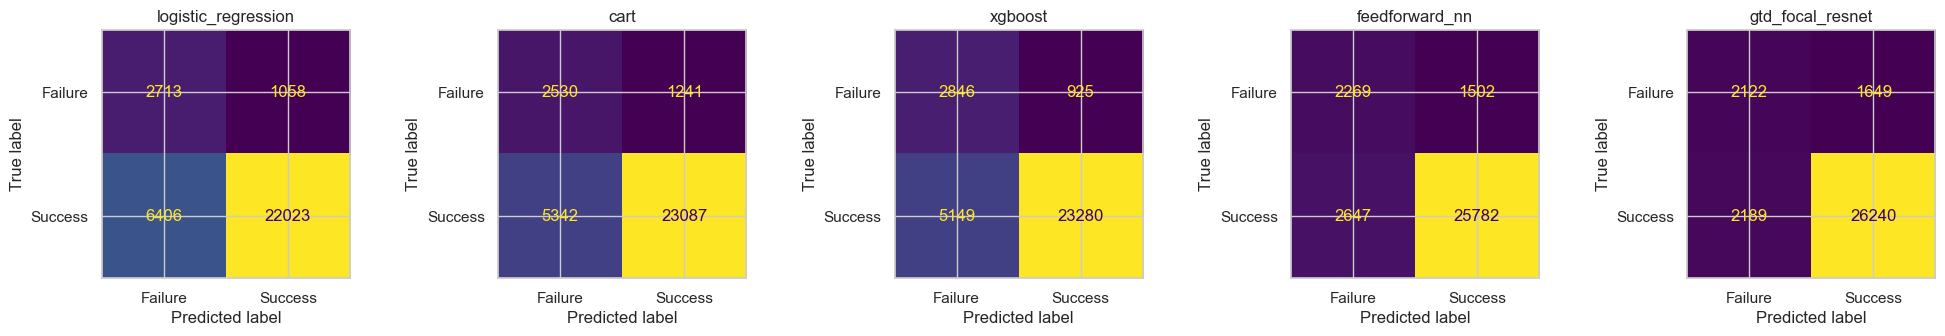

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 3.5))

if len(models)==1: axes=[axes]

for ax, (name, model) in zip(axes, models.items()):
    pred=(proba(model, X_test)>=.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Failure","Success"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig(FIG / "confusion_matrices.png", dpi=180); plt.show()


## 7. Learning curves for all models

The learning curves below use the same idea as the earlier XGBoost train-vs-validation curve, but adapted for all model types. Since Logistic Regression and CART do not train over epochs, every model is retrained on increasing fractions of the training data. Each subplot shows both the training curve and the validation curve so it is easier to see underfitting, overfitting, or stable generalization.




Learning curve: logistic_regression | train_fraction=0.1 | n=15026
Learning curve: cart | train_fraction=0.1 | n=15026
Learning curve: xgboost | train_fraction=0.1 | n=15026
Learning curve: feedforward_nn | train_fraction=0.1 | n=15026
Feedforward NN epoch 01 | loss=0.2557 | val=0.2204
Feedforward NN epoch 05 | loss=0.1741 | val=0.1690
Feedforward NN epoch 10 | loss=0.1511 | val=0.1632
Feedforward NN epoch 15 | loss=0.1323 | val=0.1678
Learning curve: gtd_focal_resnet | train_fraction=0.1 | n=15026
GTD-FocalResNet epoch 01 | loss=0.0927 | val=0.0668
GTD-FocalResNet epoch 05 | loss=0.0588 | val=0.0601
GTD-FocalResNet epoch 10 | loss=0.0499 | val=0.0640
Learning curve: logistic_regression | train_fraction=0.25 | n=37566
Learning curve: cart | train_fraction=0.25 | n=37566
Learning curve: xgboost | train_fraction=0.25 | n=37566
Learning curve: feedforward_nn | train_fraction=0.25 | n=37566
Feedforward NN epoch 01 | loss=0.2298 | val=0.2061
Feedforward NN epoch 05 | loss=0.1628 | val=0.163

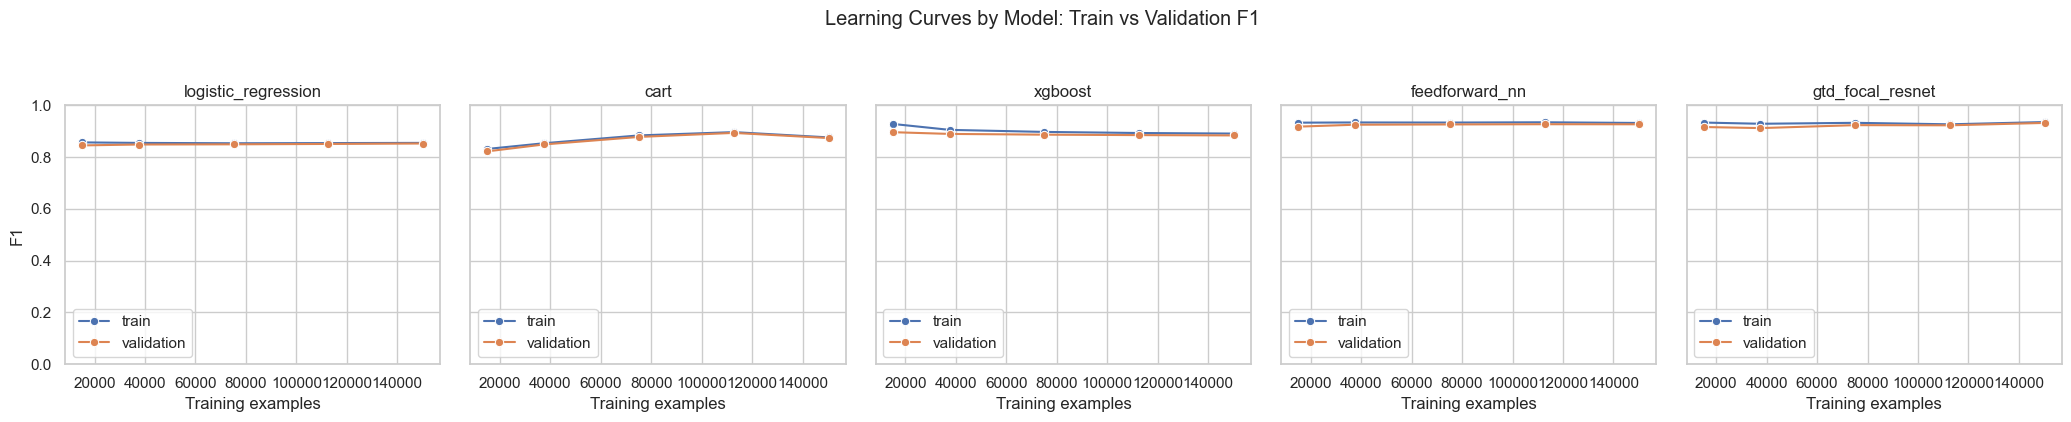

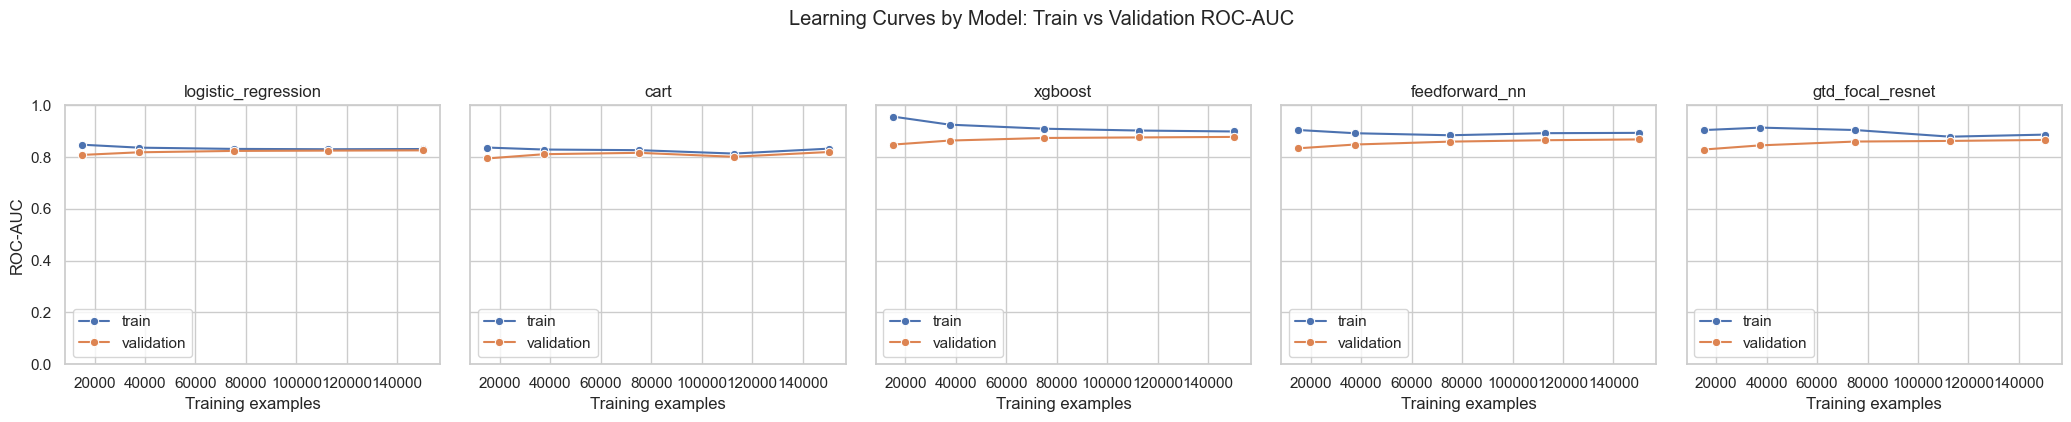

,model,split,train_fraction,train_n,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,train,0.10,15026,0.772195,0.960168,0.774084,0.857143,0.848191
1,logistic_regression,validation,0.10,15026,0.754596,0.951758,0.760597,0.845507,0.808720
2,cart,train,0.10,15026,0.737788,0.958686,0.734660,0.831854,0.837135
3,cart,validation,0.10,15026,0.722981,0.946573,0.727286,0.822565,0.795156
4,xgboost,train,0.10,15026,0.880740,0.987508,0.875999,0.928417,0.956875
5,xgboost,validation,0.10,15026,0.827391,0.951907,0.847304,0.896565,0.848601
6,feedforward_nn,train,0.10,15026,0.884933,0.955108,0.912558,0.933349,0.904995
7,feedforward_nn,validation,0.10,15026,0.858571,0.940417,0.896620,0.917996,0.834294
8,gtd_focal_resnet,train,0.10,15026,0.885465,0.953991,0.914368,0.933759,0.904727
9,gtd_focal_resnet,validation,0.10,15026,0.855714,0.936754,0.897147,0.916523,0.829521


In [9]:
if RUN_LEARNING_CURVES:
    lc_rows=[]
    base_X, base_y = X_train, y_train
    
    # Optional cap keeps the learning-curve section light enough for submission.
    if LEARNING_CURVE_MAX_TRAIN_N is not None and len(base_X) > LEARNING_CURVE_MAX_TRAIN_N:
        base_X, _, base_y, _ = train_test_split(
            base_X, base_y, train_size=LEARNING_CURVE_MAX_TRAIN_N,
            stratify=base_y, random_state=RANDOM_STATE
        )
    
    for frac in LEARNING_CURVE_FRACTIONS:
        if frac < 1:
            X_sub, _, y_sub, _ = train_test_split(
                base_X, base_y, train_size=frac,
                stratify=base_y, random_state=RANDOM_STATE
            )
        else:
            X_sub, y_sub = base_X, base_y
        
        curve_models = make_models(nn_epochs=CURVE_EPOCHS)
        for name, model in curve_models.items():
            print(f"Learning curve: {name} | train_fraction={frac} | n={len(X_sub)}")
            model.fit(X_sub, y_sub)
            for split, Xs, ys in [("train", X_sub, y_sub), ("validation", X_valid, y_valid)]:
                row = scores(name, split, ys, proba(model, Xs))
                row["train_fraction"] = frac
                row["train_n"] = len(X_sub)
                lc_rows.append(row)
    
    lc_df = pd.DataFrame(lc_rows)
    lc_df.to_csv(TAB / "learning_curves_all_models.csv", index=False)
    
    # XGBoost-style train-vs-validation curves for every model.
    model_order = list(models.keys())
    fig, axes = plt.subplots(1, len(model_order), figsize=(4.2*len(model_order), 4), sharey=True)
    if len(model_order) == 1:
        axes = [axes]
    for ax, name in zip(axes, model_order):
        sub = lc_df[lc_df.model == name]
        sns.lineplot(data=sub, x="train_n", y="f1", hue="split", marker="o", ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Training examples")
        ax.set_ylabel("F1" if ax is axes[0] else "")
        ax.set_ylim(0, 1)
        ax.legend(title="")
    fig.suptitle("Learning Curves by Model: Train vs Validation F1", y=1.05)
    plt.tight_layout()
    plt.savefig(FIG / "learning_curves_train_vs_validation_f1_all_models.png", dpi=180, bbox_inches="tight")
    plt.show()
    
    fig, axes = plt.subplots(1, len(model_order), figsize=(4.2*len(model_order), 4), sharey=True)
    if len(model_order) == 1:
        axes = [axes]
    for ax, name in zip(axes, model_order):
        sub = lc_df[lc_df.model == name]
        sns.lineplot(data=sub, x="train_n", y="roc_auc", hue="split", marker="o", ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Training examples")
        ax.set_ylabel("ROC-AUC" if ax is axes[0] else "")
        ax.set_ylim(0, 1)
        ax.legend(title="")
    fig.suptitle("Learning Curves by Model: Train vs Validation ROC-AUC", y=1.05)
    plt.tight_layout()
    plt.savefig(FIG / "learning_curves_train_vs_validation_roc_auc_all_models.png", dpi=180, bbox_inches="tight")
    plt.show()
    
    display(lc_df[["model", "split", "train_fraction", "train_n", "accuracy", "precision", "recall", "f1", "roc_auc"]])


## 8. Permutation feature importance for all models

Permutation importance is used for every model so the importance method is consistent across linear, tree, boosted-tree, and neural models. It uses F1 on a fixed test sample, so the cell may take a few minutes when all models are enabled.




Permutation importance: logistic_regression
Permutation importance: cart
Permutation importance: xgboost
Permutation importance: feedforward_nn
Permutation importance: gtd_focal_resnet


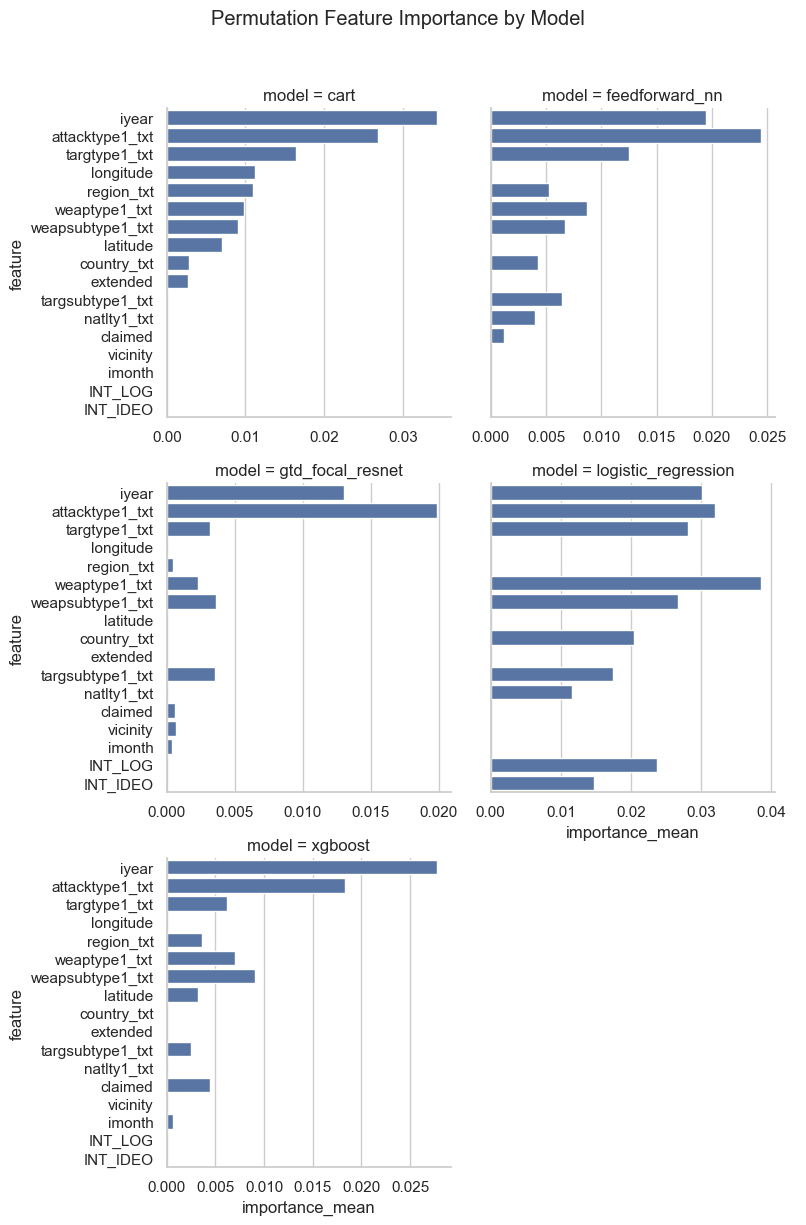

,model,feature,importance_mean,importance_std
26,cart,iyear,0.034378,0.002118
46,cart,attacktype1_txt,0.026794,0.001439
47,cart,targtype1_txt,0.016379,0.000339
31,cart,longitude,0.011221,0.000640
44,cart,region_txt,0.010913,0.000589
50,cart,weaptype1_txt,0.009829,0.000554
51,cart,weapsubtype1_txt,0.009080,0.000941
30,cart,latitude,0.007025,0.001178
45,cart,country_txt,0.002856,0.000426
29,cart,extended,0.002681,0.000239


In [10]:
if RUN_FEATURE_IMPORTANCE:
    X_imp, y_imp = X_test, y_test
    
    if len(X_imp) > PERMUTATION_SAMPLE_N:
        X_imp, _, y_imp, _ = train_test_split(X_imp, y_imp, train_size=PERMUTATION_SAMPLE_N, stratify=y_imp, random_state=RANDOM_STATE)
    
    imp_rows=[]
    
    for name, model in models.items():
        print("Permutation importance:", name)
        pi = permutation_importance(model, X_imp, y_imp, scoring="f1", n_repeats=N_PERM_REPEATS, random_state=RANDOM_STATE, n_jobs=1)
        part = pd.DataFrame({"model": name, "feature": X_imp.columns, "importance_mean": pi.importances_mean, "importance_std": pi.importances_std})
        imp_rows.append(part)
    
    imp_df=pd.concat(imp_rows, ignore_index=True).sort_values(["model","importance_mean"], ascending=[True,False])
    imp_df.to_csv(TAB / "permutation_feature_importance_all_models.csv", index=False)
    top = imp_df.groupby("model").head(10)
    g=sns.catplot(data=top, y="feature", x="importance_mean", col="model", kind="bar", col_wrap=2, sharex=False, height=4)
    g.fig.suptitle("Permutation Feature Importance by Model", y=1.02)
    
    plt.tight_layout(); plt.savefig(FIG / "feature_importance_all_models.png", dpi=180); plt.show()
    
    display(top)

## 9. Output summary

Outputs are saved under `results/light_reproducible/<split_mode>/`. Sklearn/tree models are saved as `.joblib` under `models/light_reproducible/<split_mode>/`; notebook-defined Torch models are saved there as `.pt` checkpoints with matching fitted preprocessors.





In [11]:
print("Scores:", TAB / "scores.csv")
print("Confusion matrices:", FIG / "confusion_matrices.png")
print("Learning curves:", TAB / "learning_curves_all_models.csv", FIG / "learning_curves_train_vs_validation_f1_all_models.png", FIG / "learning_curves_train_vs_validation_roc_auc_all_models.png")
print("Feature importance:", TAB / "permutation_feature_importance_all_models.csv", FIG / "feature_importance_all_models.png")

Scores: c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\tables\scores.csv
Confusion matrices: c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\figures\confusion_matrices.png
Learning curves: c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\tables\learning_curves_all_models.csv c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\figures\learning_curves_train_vs_validation_f1_all_models.png c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\figures\learning_curves_train_vs_validation_roc_auc_all_models.png
Feature importance: c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\tables\permutation_feature_importance_all_models.csv c:\Documents\Compsci\CSELEC2C\Project\results\light_reproducible\random\figures\feature_importance_all_models.png
